In [4]:
import numpy as np

# 파일 읽기 (첫 줄 헤더 무시)
data = np.loadtxt('sigma_table.txt', skiprows=1)

# 컬럼 분리
nuu = data[:, 0]
sigma = data[:, 1]

# 최대값 찾기
idx_max = np.argmax(sigma)
nu_max = nuu[idx_max]
sigma_max = sigma[idx_max]

print(f'{1/sigma_max:.2e}')
print("max sigma =", sigma_max)
print("at nu     =", nu_max)




2.67e+13
max sigma = 3.74411487717216e-14
at nu     = 1936410731614231.2


(-250.0, 250.0)

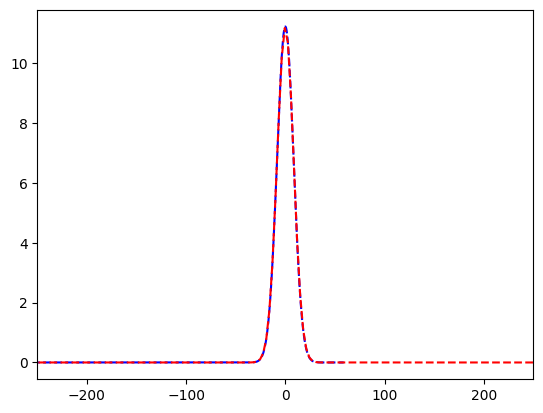

In [27]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import os
from astropy.constants import c
from astropy import constants as const
import astropy.units as u
from scipy import special
from scipy.special import wofz
from scipy.signal import find_peaks
from scipy.interpolate import interp1d

NN = int(5e4)
C_IV_N = np.linspace(1e12, 1e17, NN)
nu = np.linspace(1.8e15,2.0e15,10000) # frequency

rr = np.arange(12, 18, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()


C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

CIV_nu_K = 1.936410e15
CIV_nu_H = 1.933182e15

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm


cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s


emu_e = 1.602e-19*3e9 # Electric charge : emu
m_e = 9.10938356e-28 # Electron Mass : g 
C_IV_gamma_H = 2.64e+8 
C_IV_gamma_K = 2.65e+8 
C_IV_f12_H   = 0.0952e0
C_IV_f12_K   = 0.190e0


c_cms = 2.99792458e10  # Light Speed : cm/s


Del_V = (CIV_nu_K/ nu -1)*cc_k
V_c = 250 # km/s ()
Vsep = abs(( C_IV_H - C_IV_K) / C_IV_K)*cc_k

def H_voigt_fast(x, a):
    z = x + 1j*a
    return np.real(wofz(z))


b = 11.8
sigma0 = (np.sqrt(np.pi) * emu_e**2) / (m_e * cc)

del_nu_K = (b / cc_k) * CIV_nu_K
del_nu_H = (b / cc_k) * CIV_nu_H

x_K = (nu - CIV_nu_K) / del_nu_K
x_H = (nu - CIV_nu_H) / del_nu_H

a_K = C_IV_gamma_K / (4 * np.pi * del_nu_K)
a_H = C_IV_gamma_H / (4 * np.pi * del_nu_H)

K_term = (C_IV_f12_K / del_nu_K) * H_voigt_fast(x_K, a_K)
H_term = (C_IV_f12_H / del_nu_H) * H_voigt_fast(x_H, a_H)

cross_sec = sigma0 * (K_term + H_term)

K_region = np.where((Del_V >= -V_c) & (Del_V <= V_c))
H_region = np.where((Del_V >= Vsep - V_c) & (Del_V <= Vsep + V_c))

delV_K, cs_K = Del_V[K_region], cross_sec[K_region]
delV_H, cs_H = Del_V[H_region], cross_sec[H_region]

x_kk = delV_K / (-b)
x_hh = (delV_H - Vsep) / (-b)

tau_profile_K = C_IV_N[:, None] * cs_K
tau_profile_H = C_IV_N[:, None] * cs_H


Nciv = 3e14
plt.plot((nuu-CIV_nu_K)/CIV_nu_K *cc_k,sigma *Nciv,'b--')
plt.plot(Del_V,cross_sec * Nciv,'r--')
plt.xlim(-250,250)
# plt.xscale()